In [1]:
from tokamark.tasks import get_task_config

In [2]:
from tokamark.tasks import get_task_config,get_task_metadata; 
from tokamark.data import initialize_MAST_dataset,initialize_TokaMark_dataset; 

c=get_task_config('task_3-1'); 

m=initialize_MAST_dataset(config_task=c,shots_list=[27938],local_flag=True,use_std_scaling=False,remove_outliers=False,remove_bad_efit_rating=False,store_manager_settings={'base_local_zarr_path':'/mnt/data2/datasets/tokamark/data'});

[INFO] Local Zarr database identified under `/mnt/data2/datasets/tokamark/data` with 11573 Zarr files in it.


In [3]:
print("MAST signals:", {k: v["values"].shape for k, v in m[0].items()})

MAST signals: {'thomson_scattering-t_e': (120, 140), 'thomson_scattering-n_e': (120, 140), 'pulse_schedule-i_plasma': (1, 2789), 'pulse_schedule-n_e_line': (1, 2789), 'summary-power_nbi': (1, 2789), 'gas_injection-total_injected': (1, 2789)}


In [4]:
m[0].keys()

dict_keys(['thomson_scattering-t_e', 'thomson_scattering-n_e', 'pulse_schedule-i_plasma', 'pulse_schedule-n_e_line', 'summary-power_nbi', 'gas_injection-total_injected'])

In [5]:
m[0]['summary-power_nbi']

{'time': array([-0.12190032, -0.12165032, -0.12140032, ...,  0.57459968,
         0.57484968,  0.57509968], shape=(2789,)),
 'values': array([[ 407.81500244,  161.41894531,  745.26324463, ..., 1012.01574707,
         1009.22119141,  287.45724487]], shape=(1, 2789))}

## Task types

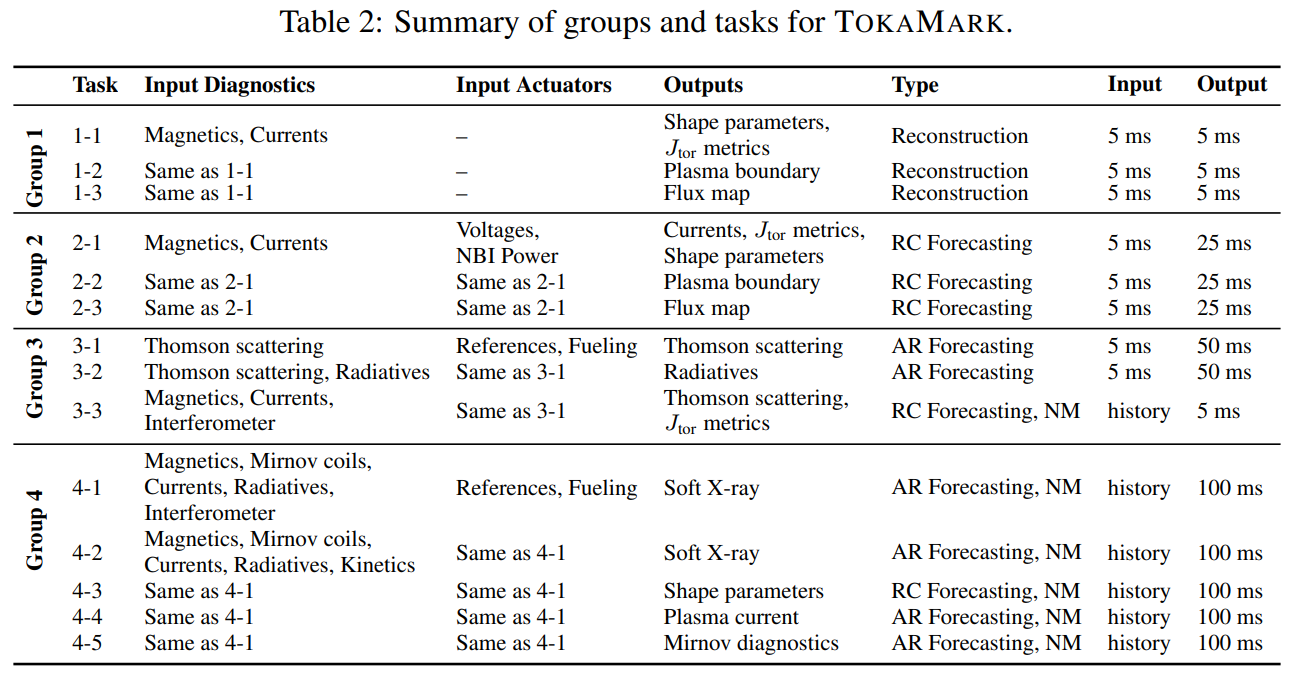

In [7]:
from tokamark.tasks import get_task_config

tasks = [
    "task_1-1", "task_1-2", "task_1-3",
    "task_2-1", "task_2-2", "task_2-3",
    "task_3-1", "task_3-2", "task_3-3",
    "task_4-1", "task_4-2", "task_4-3", "task_4-4",
]

for task in tasks:
    config = get_task_config(task)
    print(task, "->", config["task_type"])

task_1-1 -> markovian
task_1-2 -> markovian
task_1-3 -> markovian
task_2-1 -> markovian
task_2-2 -> markovian
task_2-3 -> markovian
task_3-1 -> markovian
task_3-2 -> markovian
task_3-3 -> non_markovian
task_4-1 -> non_markovian
task_4-2 -> non_markovian
task_4-3 -> non_markovian
task_4-4 -> non_markovian


In [12]:
import pandas as pd
from tokamark.tasks import get_task_config

rows = []

for group, n_tasks in [(1, 3), (2, 3), (3, 3), (4, 5)]:
    for i in range(1, n_tasks + 1):
        task = f"task_{group}-{i}"

        try:
            config = get_task_config(task)
            rows.append({
                "task": task,
                "task_type": config["task_type"],
                "input_length": config["task_window_segmenter"]["input_length"],
                "output_length": config["task_window_segmenter"]["output_length"],
                "delta": config["task_window_segmenter"]["delta"],
            })
        except Exception:
            pass

pd.DataFrame(rows)

,task,task_type,input_length,output_length,delta
0,task_1-1,markovian,0.005,0.005,-0.005
1,task_1-2,markovian,0.005,0.005,-0.005
2,task_1-3,markovian,0.005,0.005,-0.005
3,task_2-1,markovian,0.005,0.025,0.000
4,task_2-2,markovian,0.005,0.025,0.000
5,task_2-3,markovian,0.005,0.025,0.000
6,task_3-1,markovian,0.005,0.050,0.000
7,task_3-2,markovian,0.005,0.050,0.000
8,task_3-3,non_markovian,0.150,0.005,0.000
9,task_4-1,non_markovian,0.150,0.100,0.000


## Inspect Task 3-1: Profile dynamics

In [9]:
from tokamark.tasks import get_task_config, get_task_metadata
from tokamark.data import initialize_MAST_dataset, initialize_TokaMark_dataset

c = get_task_config('task_3-1')
m = initialize_MAST_dataset(
    config_task=c,
    shots_list=[27938],
    local_flag=True,
    use_std_scaling=False,
    remove_outliers=False,
    remove_bad_efit_rating=False,
    store_manager_settings={'base_local_zarr_path': '/mnt/data2/datasets/tokamark/data'},
)

print('MAST signals:', {k: v['values'].shape for k, v in m[0].items()})

tm = initialize_TokaMark_dataset(
    dataset=m,
    task_metadata=get_task_metadata(c),
    config_metadata=c,
    shuffle_windows=False,
)
w = next(iter(tm))

print()
print('WINDOW KEYS:', w.keys())
print('INPUT:', {k: v['values'].shape for k, v in w['input'].items()})
print('ACTUATOR:', {k: v['values'].shape for k, v in w['actuator'].items()})
print('OUTPUT:', {k: v['values'].shape for k, v in w['output'].items()})

[INFO] Local Zarr database identified under `/mnt/data2/datasets/tokamark/data` with 11573 Zarr files in it.
MAST signals: {'thomson_scattering-t_e': (120, 140), 'thomson_scattering-n_e': (120, 140), 'pulse_schedule-i_plasma': (1, 2789), 'pulse_schedule-n_e_line': (1, 2789), 'summary-power_nbi': (1, 2789), 'gas_injection-total_injected': (1, 2789)}

WINDOW KEYS: dict_keys(['shot_id', 'window_index', 'input', 'actuator', 'output', 't_cut'])
INPUT: {'thomson_scattering-t_e': (120, 1), 'thomson_scattering-n_e': (120, 1)}
ACTUATOR: {'pulse_schedule-i_plasma': (220,), 'pulse_schedule-n_e_line': (220,), 'summary-power_nbi': (220,), 'gas_injection-total_injected': (220,)}
OUTPUT: {'thomson_scattering-t_e': (120, 10), 'thomson_scattering-n_e': (120, 10)}


In [10]:
windows = list(tm)

print("Number of windows:", len(windows))

for w in windows[:10]:
    print(w["window_index"], w["t_cut"])

Number of windows: 571
0 -0.11690032005310058
1 -0.11590032005310058
2 -0.11490032005310058
3 -0.11390032005310058
4 -0.11290032005310058
5 -0.11190032005310058
6 -0.11090032005310058
7 -0.10990032005310058
8 -0.10890032005310057
9 -0.10790032005310057
